In [1]:
!pip install scikit-learn matplotlib pandas pdfplumber

In [2]:
import pdfplumber
import re
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt

In [3]:
def extract_text_from_pdf(pdf_path):

    text = ""

    with pdfplumber.open(pdf_path) as pdf:

        for page in pdf.pages:

            page_text = page.extract_text()

            if page_text:
                text += page_text + "\n"

    return text

In [5]:
resume_text = extract_text_from_pdf(
    r"C:\Users\raurk\OneDrive\Documents\Desktop\Prime\CareerPilotAI\notebooks\KrishnaYadavMLResume.pdf"
)

print(resume_text[:1000])

Krishna Yadav
Machine Learning Intern
(cid:131) +91-6386333833 # krishna500yadav@gmail.com (cid:239) linkedin.com/in/krishna-yadav-63a0a5331
Summary
Machine Learning Intern with hands-on experience in Python, SQL, Data Analysis, and predictive modeling.
Skilled in data preprocessing, exploratory data analysis (EDA), feature engineering, and implementing machine
learning algorithms using Scikit-Learn, Pandas, and NumPy. Familiar with Deep Learning fundamentals,
TensorFlow basics, and data visualization tools. Strong analytical and problem solving abilities with experience
building data-driven projects and working with real-world datasets.
Skills
Programming Languages: Python, SQL, C, C++
Machine Learning: Supervised & Unsupervised Learning, Regression, Classification, Clustering, Neural Networks
Tools & Libraries: Jupyter Notebook, Matplotlib, Seaborn, Git, MySQL Workbench, MS Excel
Technical Abilities: Feature Engineering, Model Evaluation, Exploratory Data Analysis (EDA), Data
Preproc

In [6]:
job_description = """
Machine Learning Intern

Requirements:

Python
Machine Learning
Deep Learning
Pandas
NumPy
Scikit-learn
TensorFlow
SQL
Git
Data Analysis

Responsibilities:

Build ML models
Data preprocessing
Model evaluation
Feature engineering
"""

In [7]:
vectorizer = TfidfVectorizer()

vectors = vectorizer.fit_transform(
    [resume_text, job_description]
)

In [8]:
similarity = cosine_similarity(
    vectors[0:1],
    vectors[1:2]
)

score = similarity[0][0] * 100

print(f"ATS Score: {score:.2f}%")

ATS Score: 29.14%


In [9]:
skills_db = [

    "python",
    "machine learning",
    "deep learning",
    "pandas",
    "numpy",
    "tensorflow",
    "sql",
    "git",
    "scikit-learn",
    "data analysis",
    "opencv",
    "streamlit",
    "java",
    "c++",
    "javascript",
    "html",
    "css"
]

In [10]:
def extract_skills(text):

    text = text.lower()

    found = []

    for skill in skills_db:

        if skill.lower() in text:

            found.append(skill)

    return found

In [11]:
resume_skills = extract_skills(resume_text)

print("Resume Skills:\n")

print(resume_skills)

Resume Skills:

['python', 'machine learning', 'deep learning', 'pandas', 'numpy', 'tensorflow', 'sql', 'git', 'scikit-learn', 'data analysis', 'java', 'c++', 'javascript', 'html', 'css']


In [12]:
jd_skills = extract_skills(job_description)

print("JD Skills:\n")

print(jd_skills)

JD Skills:

['python', 'machine learning', 'deep learning', 'pandas', 'numpy', 'tensorflow', 'sql', 'git', 'scikit-learn', 'data analysis']


In [13]:
matching_skills = list(
    set(resume_skills).intersection(
        set(jd_skills)
    )
)

print("Matching Skills:\n")

print(matching_skills)

Matching Skills:

['tensorflow', 'machine learning', 'data analysis', 'git', 'numpy', 'pandas', 'deep learning', 'sql', 'python', 'scikit-learn']


In [14]:
missing_skills = list(
    set(jd_skills) - set(resume_skills)
)

print("Missing Skills:\n")

print(missing_skills)

Missing Skills:

[]


In [15]:
skill_match = (
    len(matching_skills)
    /
    len(jd_skills)
) * 100

print(
    f"Skill Match Score: {skill_match:.2f}%"
)

Skill Match Score: 100.00%


In [16]:
if score >= 80:
    rating = "Excellent"

elif score >= 60:
    rating = "Good"

elif score >= 40:
    rating = "Average"

else:
    rating = "Needs Improvement"

print("Rating:", rating)

Rating: Needs Improvement


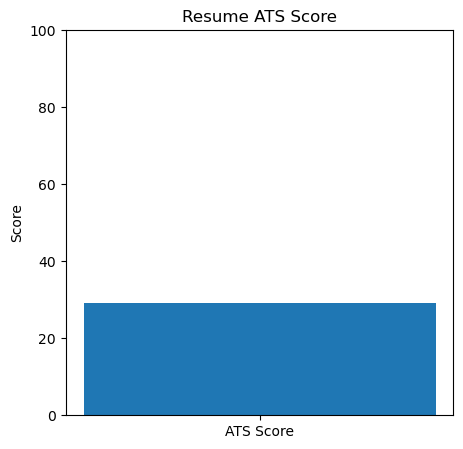

In [17]:
plt.figure(figsize=(5,5))

plt.bar(
    ["ATS Score"],
    [score]
)

plt.ylim(0,100)

plt.ylabel("Score")

plt.title("Resume ATS Score")

plt.show()

In [18]:
report = {

    "ATS Score": round(score,2),

    "Skill Match %": round(
        skill_match,
        2
    ),

    "Matching Skills": matching_skills,

    "Missing Skills": missing_skills,

    "Rating": rating
}

report

{'ATS Score': np.float64(29.14),
 'Skill Match %': 100.0,
 'Matching Skills': ['tensorflow',
  'machine learning',
  'data analysis',
  'git',
  'numpy',
  'pandas',
  'deep learning',
  'sql',
  'python',
  'scikit-learn'],
 'Missing Skills': [],
 'Rating': 'Needs Improvement'}

In [19]:
report_df = pd.DataFrame(
    [report]
)

report_df.to_csv(
     r"C:\Users\raurk\OneDrive\Documents\Desktop\Prime\CareerPilotAI\outputs/ats_report.csv",
    index=False
)

print("ATS Report Saved")

ATS Report Saved
